# import

In [15]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time, sleep
from tqdm.notebook import tqdm
import nsqdriver.nswave as nw
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
%matplotlib inline

# update firmware

In [16]:
# #PQ更新程序
# SHARED_DEVICE_MEM.clear_ip()
# UpdatedeviceIP = "192.168.110.224"
# driverUpdate = MCIDriver(UpdatedeviceIP)
# driverUpdate.open(debug=True)
# driverUpdate.set('FirmwareChange', [1,1], ["S2-O1","S13-O1"])

# init

In [17]:
SHARED_DEVICE_MEM.clear_ip()
deviceIP = "192.168.110.224"
device = MCIDriver(deviceIP, 30)
qsync = QSYNCDriver(deviceIP)
da_rate_xy=8e9
da_rate_rd=8e9
da_rate_z = 2e9
da_rate_z_l = 1e9
ad_rate=4e9
sysparam = {
    'MixMode': 1, 
    'RefClock': 'out', 
    'DArate_S2-O1': da_rate_rd, 
    'DArate_S13-O1': da_rate_xy, 
    'DArate_S12-O1': da_rate_z,
    'DArate_S15-O1': da_rate_z_l,
    'ADrate': ad_rate, 
    'CaptureMode': 0, 
    'IMixMode': 1
}
qsync_param = {'TrigFrom': 0, 'RefClock': 'in'}
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)

qsync.sync_system()
sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.9
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


# spectrum

In [18]:
freq_qubit = 0.1e9
freq_reso  = 0.1e9

In [19]:
def generate_gaussian_pulse(freq, t, fs, delay=0, rise_time_ratio=0.15):
    """
    只生成两端为0的高斯包络（无平顶），即完整高斯脉冲。
    freq: 载波频率
    t: 脉冲总时间(s)
    fs: 采样率(Hz)
    delay: 滞后（保留未用）
    rise_time_ratio: 保留未用
    """
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    # 使用标准高斯包络，两端为0
    # 使包络最大值位于脉冲中心
    center = t / 2
    std = t / 6  # 99.7%能量落在±3σ内，两端基本为0
    envelope = np.exp(-0.5 * ((time_line - center) / std) ** 2)
    carrier = np.sin(2 * np.pi * freq * time_line)
    wave = envelope * carrier
    return wave

  0%|          | 0/11 [00:00<?, ?it/s]

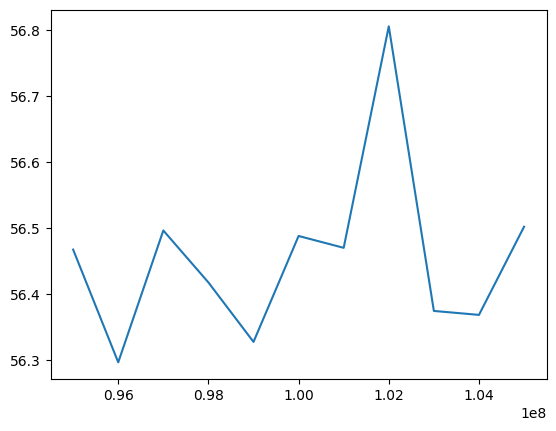

In [20]:
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3]) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)      
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var):
    srate: nw.Var = 8e9
    time_width_1: nw.Var = 2e-6
    # time_line_1: np.ndarray =np.linspace(0, time_width_1, int(time_width_1 * srate),endpoint=False)
    # wave_1: np.ndarray = amp * np.cos(2 * np.pi * time_line_1 * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

shots = 1024
period = 500e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
freq_rd = freq_reso
freqs = [freq_rd + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")
device.set('Output', 1, f"S13-O1")

probe_delay = 400e-9
probe_width = 2e-6
freq_sweep = np.linspace(freq_qubit-5e6, freq_qubit+5e6, 11)
res = []
drive_width = 2e-6
rd_delay = 220e-9
device.set('ProgramINSrc', program_cap([
    [drive_width+probe_delay+rd_delay, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
for freq_xy in tqdm(freq_sweep):
    device.set('ProgramOUTSrc', program_probe_out(freq_rd, drive_width, rd_delay, probe_width), f'S2-O1')
    device.set('ProgramOUTSrc', program_drive(freq_xy, amp=1, envelope=generate_gaussian_pulse(freq_xy,1e-6,8e9)), f'S13-O1')
    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(freq_sweep, np.array(res)[:, 0]) # 取第0个频点
plt.show()

# power rabi

  0%|          | 0/51 [00:00<?, ?it/s]

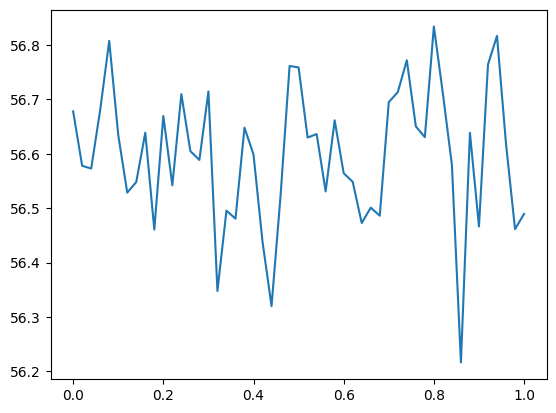

In [21]:
freq_qubit = 0.1e9
freq_reso  = 0.1e9
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var):
    srate: nw.Var = 8e9
    time_width_1: nw.Var = 2e-6
    # time_line_1: np.ndarray =np.linspace(0, time_width_1, int(time_width_1 * srate),endpoint=False)
    # wave_1: np.ndarray = amp * np.cos(2 * np.pi * time_line_1 * freq)
    
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope =nw.ins_envelope(envelope)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

shots = 1024
period = 800e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = freq_reso
freq_xy = freq_qubit
freqs = [freq_reso + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")

probe_delay = 300e-9
probe_width = 2e-6
power_sweep = np.linspace(0, 1, 51)
res = []
drive_width = 0.04e-6
rd_delay = 220e-9

import numpy as np

def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (4 * np.sqrt(np.log(2)))    
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier = np.cos(2 * np.pi * freq * time_line)
    wave = envelope * carrier*amp
    
    return wave

device.set('ProgramINSrc', program_cap([
    [drive_width+probe_delay+rd_delay, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
device.set('ProgramOUTSrc', program_probe_out(freq_rd, drive_width, rd_delay, probe_width), f'S2-O1')
for xy_power in tqdm(power_sweep):
    device.set('ProgramOUTSrc', program_drive(freq_xy, envelope=generate_gaussian_pulse(0,drive_width,8e9,0,xy_power)), f'S13-O1')
    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    #res.append(np.unwrap(np.angle(cap1.mean(axis=1))))
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(power_sweep, np.array(res)[:, 0]) # 取第0个频点
plt.show()

# time rabi

  0%|          | 0/47 [00:00<?, ?it/s]

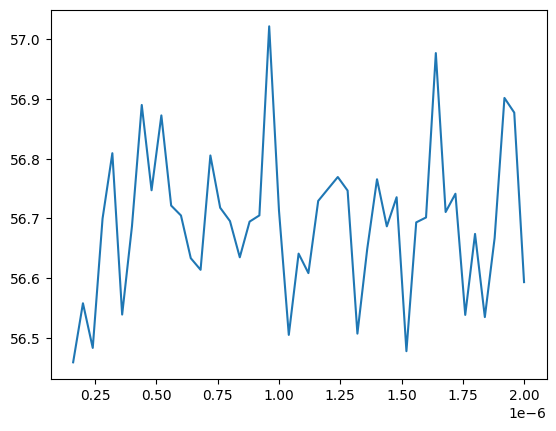

In [23]:
freq_qubit = 0.1e9
freq_reso  = 0.1e9
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3]) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel
reps = 1
@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var):
    srate: nw.Var = 8e9
    time_width_1: nw.Var = 2e-6
    # time_line_1: np.ndarray =np.linspace(0, time_width_1, int(time_width_1 * srate),endpoint=False)
    # wave_1: np.ndarray = amp * np.cos(2 * np.pi * time_line_1 * freq)
    
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope =nw.ins_envelope(envelope)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

shots = 1024
period = 800e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = freq_reso
freq_xy = freq_qubit
freqs = [freq_rd + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")
probe_delay = 300e-9
probe_width = 2e-6
time_sweep = np.arange(4, 51, 1)*40e-9# because double play actual play time is doubled
res = []
drive_width = 0.5e-6
xy_power = 0.82
rd_delay = 220e-9
for drive_time_width in tqdm(time_sweep):
    def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
        num_points = round(t * fs)
        time_line = np.linspace(0, t, num_points, endpoint=False)
        gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
        std_sq2 = t / (4 * np.sqrt(np.log(2)))    
        envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
        carrier = np.cos(2 * np.pi * freq * time_line)
        wave = envelope * carrier*amp
        
        return wave
    device.set('ProgramINSrc', program_cap([
    [drive_time_width*reps+probe_delay+rd_delay, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
    # print(freq_rd, drive_time_width, rd_delay, probe_width)
    device.set('ProgramOUTSrc', program_probe_out(freq_rd, drive_time_width*reps, rd_delay, probe_width), f'S2-O1')
    device.set('ProgramOUTSrc', program_drive(freq_xy, envelope=generate_gaussian_pulse(0,drive_time_width,8e9,0,xy_power)), f'S13-O1')
    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    # res.append(np.unwrap(np.angle((cap1.mean(axis=1)))))
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(time_sweep*reps, np.array(res)[:, 0]) # 取第0个频点
plt.show()  

# T1

In [24]:
freq_qubit = 0.1e9
freq_reso  = 0.1e9
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)  

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var):
    srate: nw.Var = 8e9
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope =nw.ins_envelope(envelope)  
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    # nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

shots = 1024
period = 1200e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

# freq_qubit = 4182700000.0
# freq_reso  = 6305000000.0
freq_rd = freq_reso
freq_xy = freq_qubit
freqs = [freq_rd + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")

probe_delay = 300e-9
probe_width = 2e-6
time_sweep = np.arange(1, 151, 3)*40e-9
drive_width = 0.4e-6
xy_power = 0.46
rd_delay = 220e-9
def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
        num_points = round(t * fs)
        time_line = np.linspace(0, t, num_points, endpoint=False)
        gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
        std_sq2 = t / (4 * np.sqrt(np.log(2)))    
        envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
        carrier = np.cos(2 * np.pi * freq * time_line)
        wave = envelope * carrier*amp
        return wave
device.set('ProgramOUTSrc', program_drive(freq_xy, envelope=generate_gaussian_pulse(0,drive_width/2,8e9,0,xy_power)), f'S13-O1')
res = []
for xy_rd_delay in tqdm(time_sweep):
    device.set('ProgramINSrc', program_cap([
    [drive_width+probe_delay+rd_delay+xy_rd_delay, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
    # print(freq_rd, drive_time_width, rd_delay, probe_width)
    device.set('ProgramOUTSrc', program_probe_out(freq_rd, xy_rd_delay, rd_delay, probe_width), f'S2-O1')
    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    cap1 = data[:, 0::cap_num]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(time_sweep*reps, np.array(res)[:, 0])
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

# T2

In [25]:
detu = 0.01e6
cap_num = 1
shots = 1024
period = 1200e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_qubit = 0.1e9+detu
freq_reso  = 0.1e9

freq_rd = freq_reso
freq_xy = freq_qubit
freqs = [freq_rd + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")

probe_delay = 300e-9
probe_width = 2e-6
time_sweep = np.arange(1, 101, 0.25)*400e-9
res = []
drive_width = 0.4e-6
xy_power = 0.82
rd_delay = 220e-9
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3]) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var, t2: nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)  

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(t2)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var,t2: nw.Var):
    srate: nw.Var = 8e9
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)    
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(t2)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel


for t2 in tqdm(time_sweep):
    half_drive_width = drive_width/2
    def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
        num_points = round(t * fs)
        time_line = np.linspace(0, t, num_points, endpoint=False)
        gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
        std_sq2 = t / (4 * np.sqrt(np.log(2)))    
        envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
        carrier = np.cos(2 * np.pi * freq * time_line)
        wave = envelope * carrier*amp
        return wave
    device.set('ProgramOUTSrc', program_drive(freq_xy,xy_power,envelope=generate_gaussian_pulse(0,half_drive_width,8e9,0,xy_power), t2=t2), f'S13-O1')
    device.set('ProgramINSrc', program_cap([
    [half_drive_width*2+probe_delay+rd_delay+t2, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
    device.set('ProgramOUTSrc', program_probe_out(freq_rd, half_drive_width*2, rd_delay, probe_width, t2), f'S2-O1')

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(time_sweep*reps, np.array(res)[:, 0]) # 取第0个频点
plt.show()

  0%|          | 0/400 [00:00<?, ?it/s]

KeyboardInterrupt: 

# T2 ECHO

In [26]:
detu = 0.030e6
cap_num = 1
shots = 1024
period = 1200e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_qubit = 0.1e9+detu
freq_reso  = 0.1e9

freq_rd = freq_reso
freq_xy = freq_qubit
freqs = [freq_rd + i * 0 for i in range(8)]
device.set('FreqList',freqs, f"S2-I1")

probe_delay = 300e-9
probe_width = 2e-6
time_sweep = np.arange(1, 199, 1)*0.4e-6
res = []
drive_width = 0.4e-6
xy_power = 0.82
rd_delay = 220e-9

def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (4 * np.sqrt(np.log(2)))    
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier = np.cos(2 * np.pi * freq * time_line)
    wave = envelope * carrier*amp
    return wave

@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0) # capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var, t2: nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)  

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(t2)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel


@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var,t2: nw.Var):
    srate: nw.Var = 8e9
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)    
        
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(t2)
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(t2)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel


for t2 in tqdm(time_sweep):#actual t2 is doubled
    half_drive_width = drive_width/2
    device.set('ProgramOUTSrc', program_drive(freq_xy,xy_power,envelope=generate_gaussian_pulse(0,half_drive_width,8e9,0,xy_power), t2=t2), f'S13-O1')
    device.set('ProgramINSrc', program_cap([
    [half_drive_width*4+probe_delay+rd_delay+t2*2, probe_width, 0, 0],
    ]*cap_num), f"S2-I1")
    device.set('ProgramOUTSrc', program_probe_out(freq_rd, half_drive_width*4, rd_delay, probe_width, t2*2), f'S2-O1')

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S2-I1", round(shots*(cap_num)))
    cap1 = data[:, 0::cap_num]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))
plt.figure()
plt.plot(time_sweep*2, np.array(res)[:, 0]) # 取第0个频点
plt.show()

  0%|          | 0/198 [00:00<?, ?it/s]

KeyboardInterrupt: 

# feedback

## init

In [27]:
SHARED_DEVICE_MEM.clear_ip()
deviceIP = "192.168.110.224"
device = MCIDriver(deviceIP, 30)
qsync = QSYNCDriver(deviceIP)
da_rate_xy=8e9
da_rate_rd=8e9
da_rate_z = 2e9
da_rate_z_l = 1e9
ad_rate=4e9
sysparam = {
    'MixMode': 1, 
    'RefClock': 'out', 
    'DArate_S2-O1': da_rate_rd, 
    'DArate_S13-O1': da_rate_xy, 
    'DArate_S12-O1': da_rate_z,
    'DArate_S15-O1': da_rate_z_l,
    'ADrate': ad_rate, 
    'CaptureMode': 0, 
    'IMixMode': 1
}
qsync_param = {'TrigFrom': 0, 'RefClock': 'in'}
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)

qsync.sync_system()
sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.9
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


## prepare

In [28]:
for ch in range(8):
    device.set('Output', 1, f'S13-O{ch+1}')
for ch in range(4):
    device.set('Output', 1, f'S2-O{ch+1}')
    
qsync.set('GT_pd',1)

In [29]:
port_name1 = 'S2-O1'
device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name1)
sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name1)
sleep(3)

port_name2 = 'S13-O1'

device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name2)
sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name2)
sleep(1e-5)

In [30]:
device.set("TerminateUpload")
device.set("CaptureMode", 0)
device.set('SetRoute', ['S2-O1', 'S13-O1'])  # 把IN-1通道的反馈消息传递给OUT1 rd 只能插在s9


## program

In [48]:
@nw.kernel
def program_xy(wave:nw.Var):
    judge_reg: nw.Reg = 0
    envelope_0: nw.Envelope = nw.ins_envelope(wave)

    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(3e-6)
    judge_reg = nw.receive(1)  # 获取广播的判决结果并存入寄存器
    if (judge_reg == 0):     # 判决
        nw.play_wave(envelope_0)
    else:
        nw.play_wave(envelope_0)
        nw.wait(1.2e-6)
        nw.play_wave(envelope_0) 
    return nw.Kernel()

def generate_gaussian_pulse(freq, t, fs=8e9, delay=0,amp =1):
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (4 * np.sqrt(np.log(2)))    
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier = np.cos(2 * np.pi * freq * time_line)
    wave = envelope * carrier*amp
    return wave

for ch in range(8):
    device.set('ProgramOUTSrc', program_xy(generate_gaussian_pulse(100e6, 1.5e-6)), f'S13-O{ch + 1}')

In [49]:
@nw.kernel
def program_probe_in():
    judge_reg0: nw.Reg = 0   
    judge_reg1: nw.Reg = 0  # 声明两个个寄存器并赋初值
    nw.set_judge(1+0j, 1000000, [0,1,2,3,4,5,6,8])  # 旋转因子，判决门限，频点选择 # real[(I+jQ)(1+j0)]
    nw.wait_for_trigger()
    nw.wait(3.1e-6)
    judge_reg0 = nw.capture(960e-9, 160e-9, 960e-9)  # 采集判决结果并赋值给寄存器0
    nw.send(judge_reg0)

    return nw.Kernel()

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)      
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

freq_rd = 10e6
device.set('FreqList',[freq_rd]*8, f"S2-I1")
drive_width = 3e-6
rd_delay = 0e-6
probe_width = 960e-9
device.set('ProgramINSrc', program_probe_in(), 'S2-I1')
device.set('ProgramOUTSrc', program_probe_out(freq_rd, drive_width, rd_delay, probe_width), 'S2-O1')

In [50]:
device.set('CaptureMode', 0)
shots = 0xfffffff0
# shots = 1024
period = 400e-6
qsync.set('Shot', shots)

device.set("StartCapture")
qsync.set('GenerateTrig', period)


In [41]:
# data = device.get('Judgment', 'S2-I1', shots)
data = device.get('IQ', 'S2-I1', shots)
data.mean()

np.complex64(4.208506e+06-2.566788e+06j)

In [51]:
qsync.set('ResetTrig')

# reset

In [3]:
SHARED_DEVICE_MEM.clear_ip()
deviceIP = "192.168.110.224"
device = MCIDriver(deviceIP, 30)
qsync = QSYNCDriver(deviceIP)
da_rate_xy=8e9
da_rate_rd=8e9
da_rate_z = 2e9
da_rate_z_l = 1e9
ad_rate=4e9
sysparam = {
    'MixMode': 1, 
    'RefClock': 'out', 
    'DArate_S2-O1': da_rate_rd, 
    'DArate_S13-O1': da_rate_xy, 
    'DArate_S12-O1': da_rate_z,
    'DArate_S15-O1': da_rate_z_l,
    'ADrate': ad_rate, 
    'CaptureMode': 0, 
    'IMixMode': 1
}
qsync_param = {'TrigFrom': 0, 'RefClock': 'in'}
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)

qsync.sync_system()
sleep(1)

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 9.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


In [4]:
for ch in range(8):
    device.set('Output', 1, f'S13-O{ch+1}')
for ch in range(4):
    device.set('Output', 1, f'S2-O{ch+1}')
    
qsync.set('GT_pd',1)

In [5]:
port_name1 = 'S2-O1'
device.set('CustomALite', [0x01F0_0000 + 2 * 4, 1], port_name1)
sleep(1e-5)
device.set('CustomALite', [0x01F0_0000 + 2 * 4, 0], port_name1)
sleep(3)

port_name2 = 'S13-O1'

device.set('CustomALite', [0x01F0_0000 + 2 * 4, 1], port_name2)
sleep(1e-5)
device.set('CustomALite', [0x01F0_0000 + 2 * 4, 0], port_name2)
sleep(1e-5)
device.set("TerminateUpload")
device.set("CaptureMode", 0)
device.set('SetRoute', ['S2-O1', 'S13-O1'])  # 把IN-1通道的反馈消息传递给OUT1 rd 只能插在s9


In [7]:
def generate_gaussian_pulse(freq, t, fs, delay=0,amp =1):
    num_points = round(t * fs)
    time_line = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (4 * np.sqrt(np.log(2)))    
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier = np.cos(2 * np.pi * freq * time_line)
    wave = envelope * carrier*amp
    return wave


In [17]:
@nw.kernel
def program_xy(freq:nw.Var, wave:np.ndarray):
    judge_reg: nw.Reg = 0
    i: nw.Var = 0
    frame_0: nw.Frame = nw.init_frame(freq, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)

    nw.wait_for_trigger()
    for i in range(3):
        nw.reset_frame()
        nw.play_wave(envelope_0, 1, 0, 0)
        nw.wait(960e-9)
        nw.wait(1000e-9)
        judge_reg = nw.receive(1)  # 获取广播的判决结果并存入寄存器
        if (judge_reg == 0):     # 判决
            nw.play_wave(envelope_0, 0.5, 0, 0)
        else:
            nw.play_wave(envelope_0, 1, 0, 0)
        nw.wait(1e-6)
    return nw.Kernel()
freq_xy = 100e6
for ch in range(8):
    device.set('ProgramOUT', program_xy(freq_xy, generate_gaussian_pulse(0,1e-6,8e9,0)), f'S13-O{ch + 1}')

In [23]:
@nw.kernel
def program_probe_in():
    judge_reg0: nw.Reg = 0   
    judge_reg1: nw.Reg = 0  # 声明两个个寄存器并赋初值
    i: nw.Var = 0
    nw.set_judge(1+0j, -30003501, [0,1,2,3,4,5,6,8])  # 旋转因子，判决门限，频点选择 # real[(I+jQ)(1+j0)]
    nw.wait_for_trigger()
    for i in range(3):
        nw.wait(2e-6)
        judge_reg0 = nw.capture(960e-9, 0, 0)  # 采集判决结果并赋值给寄存器0
        nw.send(judge_reg0)
        nw.wait(1e-6)
        nw.wait(1e-6)

    return nw.Kernel()

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    i: nw.Var = 0
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)      
    nw.wait_for_trigger()
    nw.reset_frame()
    for i in range(3):
        nw.wait(drive_width)
        nw.wait(rd_delay)
        nw.wait(1000e-9)
        nw.play_wave(envelope_1, 1, 0, 0)
        nw.wait(1e-6)
        nw.wait(1e-6)
    
    return nw.Kernel

freq_rd = 100e6
device.set('FreqList',[freq_rd]*8, f"S2-I1")
drive_width = 1e-6
rd_delay = 0e-6
probe_width = 960e-9
device.set('ProgramIN', program_probe_in(), 'S2-I1')
device.set('ProgramOUT', program_probe_out(freq_rd, drive_width, rd_delay, probe_width), 'S2-O1')

In [22]:
device.set('CaptureMode', 0)
shots = 0xfffffff0
# shots = 1024
period = 400e-6
qsync.set('Shot', shots)

device.set("StartCapture")
qsync.set('GenerateTrig', period)


In [11]:
data = device.get('IQ', 'S2-I1', shots)
data[:64]

array([[ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j],
       [ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j],
       [ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j],
       ...,
       [ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j],
       [ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j],
       [ -214252.+1568253.j,  1181132.-1172223.j, -1726995. +261602.j,
        ...,  1181742.-1172806.j, -1727625. +261837.j,
         -155087.+1534981.j]], dtype=complex64)

In [24]:
qsync.set('ResetTrig')

In [12]:
data.mean()

(-233501.81+209550.5j)